In [ ]:
from analyzer import * 

mm = MMStarResults()
vv = VQAResults()   
human_vqa = vv.human 
human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]  

In [51]:
vt = vv.test_model
vt['dataset'] = 'VQA'
vt = vt.fillna('Pretrained') 
vt = vt.rename(columns={'correct': 'acc', 'answer_type': 'category'}) 
vt = vt[vt['condition'] == ''].groupby(
    ['dataset', 'strategy', 'blind', 'trained_dataset', 'model', 'finetuned', 'category',]
    )[['acc', 'answer_similarity']].mean().reset_index()
    
vt = vt.melt(id_vars=[col for col in vt.columns if col not in ['acc', 'answer_similarity']], 
        value_vars=['acc', 'answer_similarity'], var_name='score_type', value_name='score')     
vt.finetuned.unique() 

mt = mm.test_model 
mt['dataset'] = 'MMStar'
mt['score_type'] = 'acc'
mt = mt.rename(columns={'correct': 'score'}) 
mt = mt[mt['condition'] == ''].groupby(['dataset', 'strategy', 'blind', 'trained_dataset', 'model', 'finetuned', 'category', 'score_type'])['score'].mean().reset_index()

dd = pd.concat([vt, mt])
dd = dd.rename(columns={'correct': 'score'})
dd = dd[dd['score_type'] == 'acc']
dd['blind'] = dd['blind'].fillna('Pretrained')

acc = (
    dd[(dd['trained_dataset'] != 'MMStar') & (dd['score_type'] == 'acc') & (dd['strategy'] != 'SFT')]
    # .drop_duplicates(['model', 'blind', 'trained_dataset' , 'strategy', 'dataset', 'category'])
    .pivot_table(
        index=['model', 'blind',  ], #'trained_dataset' , 'strategy' 
        columns=['dataset', 'category'],
        values='score' 
    ) 
).dropna(axis=0) # .to_csv('./tables/finetuned-acc-category.csv', float_format="%.1f", encoding='utf-8') # .reset_index(level=0, drop=True) #
blind_order = ['Pretrained', 'GT', 'Blind', ]

acc = acc.reindex(
    blind_order, 
    level='blind'
) 

In [53]:
acc.to_latex(f'./tables/acc_by-category.tex', float_format="%.1f")

In [ ]:
pivot = (
    dd[
        (dd['trained_dataset'] == 'VQA') & (dd['dataset'] == 'VQA')
    ]
    .pivot_table(
        index=['model', 'strategy'],
        columns=['blind', 'dataset', 'score_type'],
        values='score'
    )
)

sft_js_comparison = pivot['GT'] - pivot['Blind']
sft_js_comparison.to_latex(f'./tables/sft_js_comparison.tex', float_format="%.1f")  

In [ ]:
delta = (
    (dd[(dd['trained_dataset'] == 'VQA') & (dd['strategy'] == 'JS') ] # & (dd['score_type'] == 'acc') 
    .pivot_table(
        index=['model', 'blind'], # , 'strategy' 
        columns=['dataset', 'category' ,'score_type' ], #  
        values='score'
    ) ) 
) 
delta 

In [3]:
mt = mm.finetuning_effect(mm.test_model) 
vt = vv.finetuning_effect(vv.test_model) 
vt = vt.rename(columns={'answer_type' : 'category'})
mt['score_type'] = 'accuracy' 
dd = pd.concat([vt, mt])  # .to_csv('./tables/finetuned-delta-sim-category.csv', float_format="%.1f", encoding='utf-8') # .reset_index(level=0, drop=True) # 

In [ ]:
delta = (
    (dd[(dd['trained_dataset'] == 'VQA') & (dd['strategy'] == 'JS') ] # & (dd['score_type'] == 'acc') 
    .pivot_table(
        index=['model', 'blind'], # , 'strategy' 
        columns=['dataset', 'category' ,'score_type' ], #  
        values='score'
    ) ) 
) 
delta 

delta                            
dataset                              MMStar       VQA                  
score_type                         accuracy  accuracy answer_similarity
model              blind strategy                                      
InternVL 3.5 (8B)  Blind JS        0.159617 -0.142371          0.025373
                         SFT      -0.558659 -0.043473          0.038740
                   GT    JS        0.159617  0.499973          0.409360
                         SFT       0.478851  0.466493          0.466340
LLaVA‑Mistral (7B) Blind JS        3.617984 -1.353307         -0.580273
                         SFT       4.549082 -1.813447         -0.866980
                   GT    JS        2.633679 -1.079880         -0.539620
                         SFT       5.746209 -1.046493         -0.627520
Qwen3‑VL (4B)      Blind JS       -3.325352 -0.308936          0.062460
                         SFT      -3.910615 -0.706727          0.084940
                   GT    JS       -3.192338  0.193387          0.130520
                         SFT      -2.553871 -0.060000         -0.031680
Qwen3‑VL (8B)      Blind JS       -2.873105 -0.155549          0.062473
                         SFT      -2.793296 -0.333363          0.021200
                   GT    JS       -2.314445  0.080053          0.108060
                         SFT      -1.516361  0.253407          0.180140

In [ ]:
acc, delta = acc.align(delta)

acc_str = acc.applymap(
    lambda x: f"{x:.1f}" if pd.notna(x) else ""
)

delta_str = delta.applymap(
    lambda x: f"{x:+.1f}" if pd.notna(x) else ""
)

combined = (
    acc_str
    + " {\\scriptsize("
    + delta_str
    + ")}"
)

combined = combined.where(acc.notna() & delta.notna(), "")
combined.to_latex(
    "./tables/finetuned-acc-delta-category.tex",
    escape=False
) 

/tmp/ipykernel_616186/1337095857.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acc_str = acc.applymap(
/tmp/ipykernel_616186/1337095857.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  delta_str = delta.applymap(


In [42]:
dd = pd.concat([vt, mt]) 
dd[dd['trained_dataset']=='VQA'].pivot_table(
            index=['trained_dataset', 'model', 'blind', 'strategy'],  #  , 'finetuned' 
            columns=['dataset', 'category'] ,
            values=['delta']).assign(Average=lambda x: x.mean(axis=1)).reset_index(level=0, drop=True) # .to_latex('./tables/finetuned-acc-category.tex', float_format="%.2f")

KeyError: 'delta'

In [ ]:

pd.merge(mmstar, vqa.reset_index(), on=['model', 'finetuned'], suffixes=(' MMStar', ' VQA')) 

In [ ]:

vqadf, vqapt = vv.finetuning_effect(test_model) 
vqadf = vqadf.melt(id_vars=['model', 'finetuned', 'model_size', 'question_id', 'answer_type', 'question_type'], value_vars=['delta_acc', 'delta_sim'], var_name='score_type', value_name='delta') 
# vqadf.groupby(['model', 'finetuned', 'model_size', 'score_type']).count()
vqa=vqadf.pivot_table(index=['model', 'finetuned', 'model_size'], columns=['answer_type'], values=['delta']).droplevel(0, axis=1) 

model_mg = vv.model_mg
test_model_mg = vv.test_model_mg # get_mg(test_model, filename='5k-test')   

In [ ]:

dfdf = mm.finetuning_effect(mm.test_model)
dfdf.groupby(['model', 'finetuned'])[['correct', 'correct_baseline']].count()

mmstar = dfdf.pivot_table(
    index=['model', 'finetuned'], # ['model', 'family', 'model_size', 'finetuned'], 
    values='delta', 
    aggfunc='mean'
).reset_index() 

dd = dd[dd['finetuned']!='JS-Blind VQA (n=10)']
            index=['trained_dataset', 'model', 'strategy'],  #  , 'finetuned' 

pd.merge(mmstar, vqa.reset_index(), on=['model', 'finetuned'], suffixes=(' MMStar', ' VQA')) 


In [ ]:

dd[dd['trained_dataset']=='MMStar'].pivot_table(
            columns=['bias'] , 
            values=['delta']).assign(Average=lambda x: x.mean(axis=1)).reset_index(level=0, drop=True).to_latex('./tables/spubench-mmstar_finetuned-delta.tex', float_format="%.2f")
             
dd[dd['trained_dataset']=='VQA'].pivot_table(
            index=['trained_dataset', 'model', 'strategy', 'blind'],  #  , 'finetuned' 
            columns=['bias'] , 
            values=['delta']).assign(Average=lambda x: x.mean(axis=1)).reset_index(level=0, drop=True).to_latex('./tables/spubench-VQA_finetuned-delta.tex', float_format="%.2f")
             

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_theme(
    style="whitegrid",
    context="paper",
)  

dfdf.pivot_table(
    index=['model', 'finetuned'], 
    columns='category', 
    values='delta', 
    aggfunc='mean'
).to_csv("./tables/appendix-mmstar-category-heatmap.csv") 

plt.figure(figsize=(7,7))
pt = dfdf.pivot_table(
    index=['model', 'finetuned'], 
    columns='category', 
    values='delta', 
    aggfunc='mean'
)
ax = sns.heatmap(pt, 
    annot=True,
    fmt=".1f",
    cmap="RdBu_r", # 
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Δ Score "}
)
# ax.set_xticklabels(categories, rotation=0)
# ax.set_yticklabels(models, rotation=0)
# plt.title("Blind Training Improves Reasoning-Oriented Categories", pad=10)
plt.tight_layout()
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 700x700 with 0 Axes>

<Axes: xlabel='cc_quadrant', ylabel='MG'>

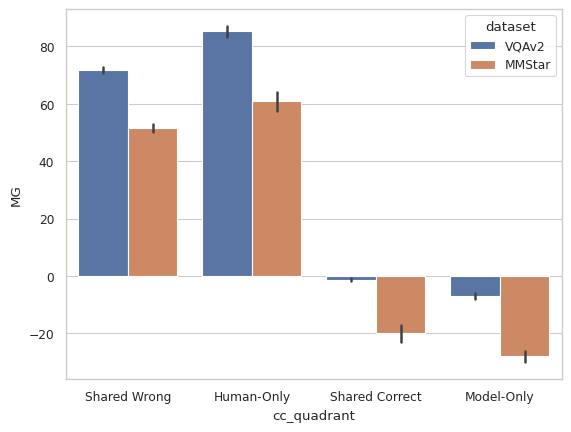

In [ ]:
vvs= vv.quadrants() 
vvs[vvs['finetuned'] == 'Pretrained'].groupby("cc_quadrant")["MG"].agg(['count', 'mean']).to_latex('./tables/quadrant-vqa.tex', float_format="%.1f") 

mms = mm.get_quadrants()
mms[mms['finetuned'] == 'Pretrained'].groupby("cc_quadrant")["MG"].agg(['count', 'mean']).to_latex('./tables/quadrant-mmstar.tex', float_format="%.1f")   

vvs['dataset'] = 'VQAv2' 
mms['dataset'] = 'MMStar'

qmg = pd.concat([vvs, mms]).reset_index()
# qmg= qmg[qmg['finetuned'] == "Pretrained"]  
qmg.pivot_table(
    index=['cc_quadrant'] , 
    values=['MG'] , 
    columns=['dataset'] , 
    aggfunc = ['count', 'mean'] ).to_latex('./tables/quadrant-stats.tex', float_format="%.1f") 
sns.barplot(qmg, x='cc_quadrant', y='MG', hue='dataset') 

### Correlations 

In [ ]:
res_HH, res_MM, res_HM  = get_agreements(human_vqa, model_vqa, n_boot=0)  # accuarcy 
corr_mat = get_all_cm(res_HH, res_MM, res_HM )
acc_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='acc_corr') 
plot_unified_agreement_heatmap(corr_mat, res_HH['corr_mat'].columns, res_MM['corr_mat'].columns, 'Human–Model Agreement (Accuracy)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-acc.png') 
acc = pd.concat([result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)]) 

res_HH['corr_mat'].mean().reset_index().to_csv('./corr/acc-humans-n6.csv', encoding="utf-8-sig")
res_MM['corr_mat'].mean().reset_index().to_csv('./corr/acc-models-toM.csv', encoding="utf-8-sig")
res_HM['corr_mat'].mean().reset_index().to_csv('./corr/acc-models-toH-n6.csv', encoding="utf-8-sig")

In [ ]:
res_HH, res_MM, res_HM  =  get_agreements(human_vqa, model_vqa, 'answer_similarity', n_boot=0) 
corr_mat = get_all_cm(res_HH, res_MM, res_HM ) 
sim_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='sim_corr') 
pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
acc = pd.concat([acc, result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)])
plot_unified_agreement_heatmap(corr_mat,  res_HH['corr_mat'].columns, res_MM['corr_mat'].columns, 'Human–Model Agreement (Emb Similarity)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-sim.png') 
transform_corr_table(acc) # .to_latex('./tables/appendix/3_spearman-interrater-vqa-finetuned.tex', float_format="%.3f")   

In [ ]:

if isinstance(mg_df.columns, pd.MultiIndex):
    mg_df.columns = ['_'.join(str(c) for c in col if c != '') for col in mg_df.columns.values]

In [ ]:
# from utils.plots import scatterplot, get_family, parse_size 
from utils.plots import scatterplot_finetuned 
import pandas as pd
from utils.corr import corr_by_regime

pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
pcorr= pd.merge(pcorr.reset_index(), mg_df.reset_index(), on=['model'])  
pcorr = pcorr[~pcorr['model'].str.contains('MMStar')]
pcorr = pcorr[['model', 'acc_corr', 'sim_corr', 'MG_Acc', 'MG_S']]

pcorr = pcorr[~pcorr['model'].str.contains('|'.join(exclude_models))]
corr_by_regime(pcorr).to_latex('./tables/appendix/finetuned-pearson-r.tex', float_format="%.1f")    

for fam in pcorr.family.unique(): 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='acc_corr', y_col='MG_Acc', title=f'{fam} accuracy') # 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='sim_corr', y_col='MG_S', title=f'{fam} similairty') # 

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(
    pt,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    # vmin=0, vmax=1,
    linewidths=0.5
)
plt.ylabel("Model")
plt.xlabel("Spurious correlation type")
plt.title("Accuracy by model and spurious correlation type")
plt.tight_layout()
plt.show() # spu-corr-finetune.png